# Bitcoin Prophet and Deferred Models

## Role
Describe and evaluate the periodic-refit Prophet comparator; record deferred models.

## Inputs
Frozen Prophet and validated vectors.

## Outputs
Artifact-derived Prophet metrics and model-status table.

## Depends On
01.

## Authoritative Status
SUPPORTING VALIDATED COMPARATOR

## What This Notebook Does Not Do
It does not refit Prophet, install packages, or execute deferred models.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


## Prophet protocol
Prophet uses 128 historical prices at each refit origin and refits every 30 forecast dates. It is past-only but does not update daily, so it is not operationally identical to daily-updated rolling one-step systems.

In [2]:
# Load the canonical split and frozen Prophet forecast.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

# Compute and display the unchanged Prophet metrics.
metric_table(
    validated.Actual,
    {'Prophet — 30-Day Periodic Refit': validated.Prophet_Periodic_Refit},
    train,
)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Prophet — 30-Day Periodic Refit,8195.262862,10781.162873,11.199767,11.287185,29.060658,1061


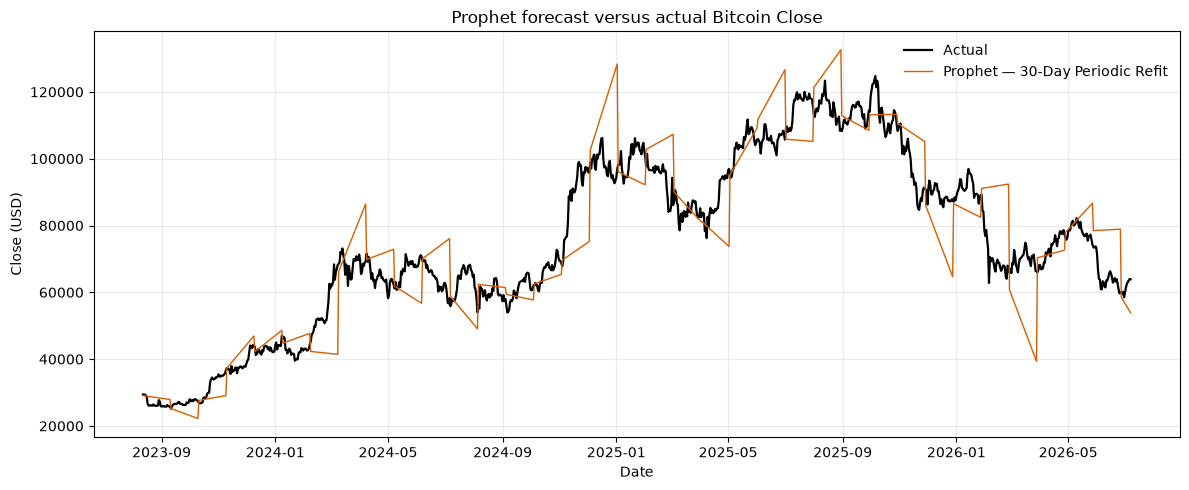

In [3]:
import matplotlib.pyplot as plt

# Compare the periodic-refit Prophet forecast with held-out actual prices.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Prophet_Periodic_Refit, color='#D55E00', linewidth=1.0, label='Prophet — 30-Day Periodic Refit')
ax.set(title='Prophet forecast versus actual Bitcoin Close', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [4]:
# Record model availability without executing deferred systems.
pd.DataFrame({
    'Model': ['Moirai', 'PatchTST', 'iTransformer', 'Informer', 'Autoformer'],
    'Status': ['Unavailable', 'Deferred', 'Deferred', 'Unavailable / unexecuted', 'Unavailable / unexecuted'],
})

,Model,Status
0,Moirai,Unavailable
1,PatchTST,Deferred
2,iTransformer,Deferred
3,Informer,Unavailable / unexecuted
4,Autoformer,Unavailable / unexecuted


## Key Findings

The periodic-refit Prophet path visibly lags portions of the held-out series, consistent with its displayed error metrics under 30-day refitting. The remaining listed models were not executed for this evidence set, so no forecast or performance claim is made for them.